In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Dataset
fedex_df = pd.read_csv('/content/SCMS_Delivery_History_Dataset.csv')
print('The dataset has be loaded')

The dataset has be loaded


In [4]:
# Dataset First Look
fedex_df.head(10)

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN
5,23,112-NG-T01,Pre-PQ Process,SCMS-87,ASN-57,Nigeria,PMO - US,Direct Drop,EXW,Air,...,240,416,2225.60,5.35,0.02,"Aurobindo Unit III, India",Yes,504,5920.42,NaN
6,44,110-ZM-T01,Pre-PQ Process,SCMS-139,ASN-130,Zambia,PMO - US,Direct Drop,DDU,Air,...,90,135,4374.00,32.40,0.36,MSD South Granville Australia,Yes,328,Freight Included in Commodity Cost,NaN
7,45,109-TZ-T01,Pre-PQ Process,SCMS-140,ASN-94,Tanzania,PMO - US,Direct Drop,EXW,Air,...,60,16667,60834.55,3.65,0.06,"Aurobindo Unit III, India",Yes,1478,6212.41,NaN
8,46,112-NG-T01,Pre-PQ Process,SCMS-156,ASN-93,Nigeria,PMO - US,Direct Drop,EXW,Air,...,60,273,532.35,1.95,0.03,"Aurobindo Unit III, India",No,See ASN-93 (ID#:1281),See ASN-93 (ID#:1281),NaN
9,47,110-ZM-T01,Pre-PQ Process,SCMS-165,ASN-199,Zambia,PMO - US,Direct Drop,CIP,Air,...,120,2800,115080.00,41.10,0.34,ABBVIE (Abbott) St. P'burg USA,Yes,643,Freight Included in Commodity Cost,NaN


In [5]:
# Dataset Rows & Columns count
fedex_df.shape

(10324, 33)

In [6]:
# Dataset Info
fedex_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

In [7]:
# Dataset Duplicate Value Count
fedex_df.duplicated().sum()

np.int64(0)

In [8]:
# Missing Values/Null Values Count
fedex_df.isnull().sum()

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


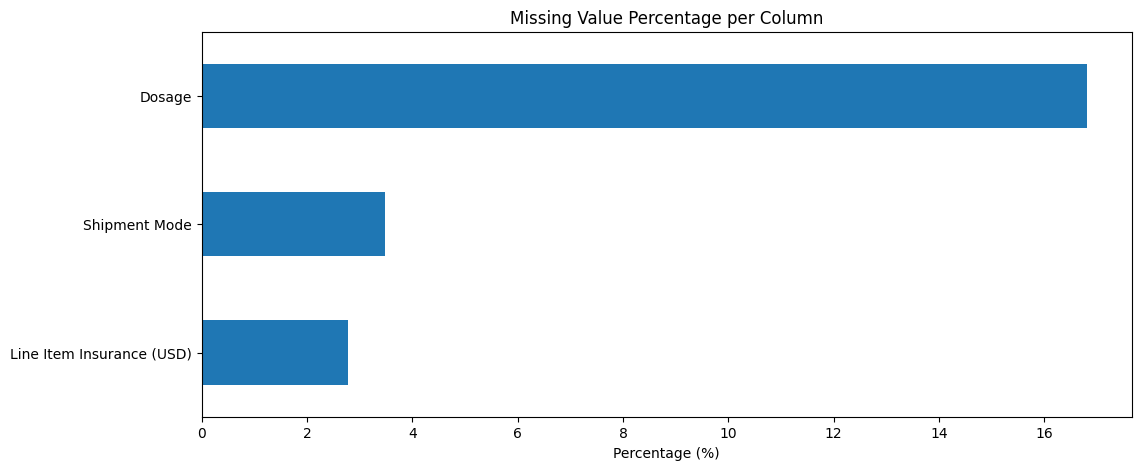

In [9]:
# Visualizing the missing values
missing = fedex_df.isnull().mean() * 100
missing = missing[missing > 0]

plt.figure(figsize=(12,5))
missing.sort_values().plot(kind='barh')
plt.title("Missing Value Percentage per Column")
plt.xlabel("Percentage (%)")
plt.show()

In [10]:
# Dataset Columns
fedex_df.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [11]:
# Dataset Describe
fedex_df.describe(include='all')

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324,10324,10324,10324,10324,9964,...,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324,10324,10324,10324,10037.000000
unique,NaN,142,1237,6233,7030,43,4,2,8,4,...,NaN,NaN,NaN,NaN,NaN,88,2,4688,6733,NaN
top,NaN,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,...,NaN,NaN,NaN,NaN,NaN,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,NaN
freq,NaN,768,2681,67,54,1406,10265,5404,5404,6113,...,NaN,NaN,NaN,NaN,NaN,3172,7030,1507,1442,NaN
mean,51098.968229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,NaN,NaN,NaN,NaN,240.117626
std,31944.332496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,NaN,NaN,NaN,NaN,500.190568
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,12795.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.000000,408.000000,4.314593e+03,4.120000,0.080000,NaN,NaN,NaN,NaN,6.510000
50%,57540.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,NaN,NaN,NaN,NaN,47.040000
75%,83648.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,NaN,NaN,NaN,NaN,252.400000


In [12]:
# Check Unique Values for each variable.
fedex_df.nunique()

,0
ID,10324
Project Code,142
PQ #,1237
PO / SO #,6233
ASN/DN #,7030
Country,43
Managed By,4
Fulfill Via,2
Vendor INCO Term,8
Shipment Mode,4


In [13]:
#1-Clean Column Names
fedex_df.columns = fedex_df.columns.str.replace(" ", "_").str.lower()

In [14]:
fedex_df.columns

Index(['id', 'project_code', 'pq_#', 'po_/_so_#', 'asn/dn_#', 'country',
       'managed_by', 'fulfill_via', 'vendor_inco_term', 'shipment_mode',
       'pq_first_sent_to_client_date', 'po_sent_to_vendor_date',
       'scheduled_delivery_date', 'delivered_to_client_date',
       'delivery_recorded_date', 'product_group', 'sub_classification',
       'vendor', 'item_description', 'molecule/test_type', 'brand', 'dosage',
       'dosage_form', 'unit_of_measure_(per_pack)', 'line_item_quantity',
       'line_item_value', 'pack_price', 'unit_price', 'manufacturing_site',
       'first_line_designation', 'weight_(kilograms)', 'freight_cost_(usd)',
       'line_item_insurance_(usd)'],
      dtype='object')

In [15]:
#Convert Date Columns
date_cols = ["PQ First Sent to Client Date", "PO Sent to Vendor Date",
             "Scheduled Delivery Date", "Delivered to Client Date"]

for col in date_cols:
    if col in fedex_df.columns:
        fedex_df[col] = pd.to_datetime(fedex_df[col], errors='coerce')

In [16]:
pd.set_option('display.max_columns', None)

In [17]:
#Convert Numeric Columns
num_cols = ["line_item_quantity", "line_item_value",
            "pack_price", "unit_price", "weight_kilograms", "freight_cost_usd"]

for col in num_cols:
    if col in fedex_df.columns:
        fedex_df[col] = pd.to_numeric(fedex_df[col], errors="coerce")

In [19]:
#Lead Time(in Days)
# Ensure date columns are converted to datetime type before calculation
fedex_df["delivered_to_client_date"] = pd.to_datetime(fedex_df["delivered_to_client_date"], errors='coerce')
fedex_df["po_sent_to_vendor_date"] = pd.to_datetime(fedex_df["po_sent_to_vendor_date"], errors='coerce')
fedex_df["lead_time"] = (fedex_df["delivered_to_client_date"] - fedex_df["po_sent_to_vendor_date"]).dt.days

/tmp/ipykernel_2063/2026959855.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fedex_df["delivered_to_client_date"] = pd.to_datetime(fedex_df["delivered_to_client_date"], errors='coerce')
/tmp/ipykernel_2063/2026959855.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fedex_df["po_sent_to_vendor_date"] = pd.to_datetime(fedex_df["po_sent_to_vendor_date"], errors='coerce')


In [20]:
#On-Time Delivery Flag
fedex_df["on_time"] = np.where(
    fedex_df["delivered_to_client_date"] <= fedex_df["scheduled_delivery_date"], 1, 0
)

In [21]:
print(fedex_df.columns.tolist())

['id', 'project_code', 'pq_#', 'po_/_so_#', 'asn/dn_#', 'country', 'managed_by', 'fulfill_via', 'vendor_inco_term', 'shipment_mode', 'pq_first_sent_to_client_date', 'po_sent_to_vendor_date', 'scheduled_delivery_date', 'delivered_to_client_date', 'delivery_recorded_date', 'product_group', 'sub_classification', 'vendor', 'item_description', 'molecule/test_type', 'brand', 'dosage', 'dosage_form', 'unit_of_measure_(per_pack)', 'line_item_quantity', 'line_item_value', 'pack_price', 'unit_price', 'manufacturing_site', 'first_line_designation', 'weight_(kilograms)', 'freight_cost_(usd)', 'line_item_insurance_(usd)', 'lead_time', 'on_time']


In [22]:
#Basic KPIs
print("Total Shipments:", len(fedex_df))
print("Average Lead Time:", fedex_df["lead_time"].mean())
print("On-Time Delivery Rate:", fedex_df["on_time"].mean())

Total Shipments: 10324
Average Lead Time: 105.55858013937282
On-Time Delivery Rate: 0.8851220457187137


In [23]:
#Converting 'Weight_(kilogram)' and 'freight_cost_(usd)' datatype from 'Object' to 'float'
# Clean Weight (Kilograms)
fedex_df['weight_(kilograms)'] = (
    fedex_df['weight_(kilograms)']
    .astype(str)
    .str.replace(",", "")                # remove commas
    .str.replace("$", "")                # remove currency symbols (just in case)
    .str.extract(r'(\d*\.?\d+)')          # extract numeric part only
)

fedex_df['weight_(kilograms)'] = pd.to_numeric(fedex_df['weight_(kilograms)'], errors='coerce')

# Clean Freight Cost (USD)
fedex_df['freight_cost_(usd)'] = (
    fedex_df['freight_cost_(usd)']
    .astype(str)
    .str.replace(",", "")
    .str.replace("$", "")
    .str.extract(r'(\d*\.?\d+)')          # extract only digits + decimals
)

fedex_df['freight_cost_(usd)'] = pd.to_numeric(fedex_df['freight_cost_(usd)'], errors='coerce')


#Verify Conversion
fedex_df[['weight_(kilograms)', 'freight_cost_(usd)']].info()
fedex_df[['weight_(kilograms)', 'freight_cost_(usd)']].head()

#Handling Missing or Invalid Values
fedex_df['weight_(kilograms)'] = fedex_df['weight_(kilograms)'].fillna(fedex_df['weight_(kilograms)'].median())
fedex_df['freight_cost_(usd)'] = fedex_df['freight_cost_(usd)'].fillna(fedex_df['freight_cost_(usd)'].median())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   weight_(kilograms)  8817 non-null   float64
 1   freight_cost_(usd)  8643 non-null   float64
dtypes: float64(2)
memory usage: 161.4 KB


In [27]:
#Freight Cost Per KG
# Replace 0 in weight_(kilograms) with NaN to avoid division by zero, then calculate freight_per_kg
fedex_df["freight_per_kg"] = fedex_df["freight_cost_(usd)"] / fedex_df["weight_(kilograms)"].replace(0, np.nan)

In [28]:
#Basic KPIs
print("Total Freight Cost:", fedex_df["freight_cost_(usd)"].sum())
print("Average Freight per KG:", fedex_df["freight_per_kg"].mean())

Total Freight Cost: 88983092.41
Average Freight per KG: 26.01693536121676


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Lead Time Distribution

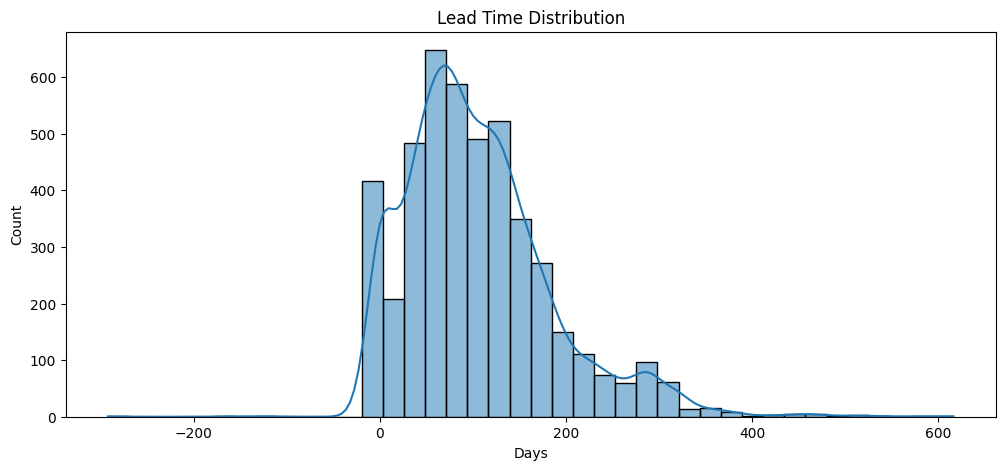

In [29]:
plt.figure(figsize=(12,5))
sns.histplot(fedex_df["lead_time"].dropna(), bins=40, kde=True)
plt.title("Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

#### Chart - 2 Freight Cost Distribution

<Axes: xlabel='freight_cost_(usd)', ylabel='Count'>

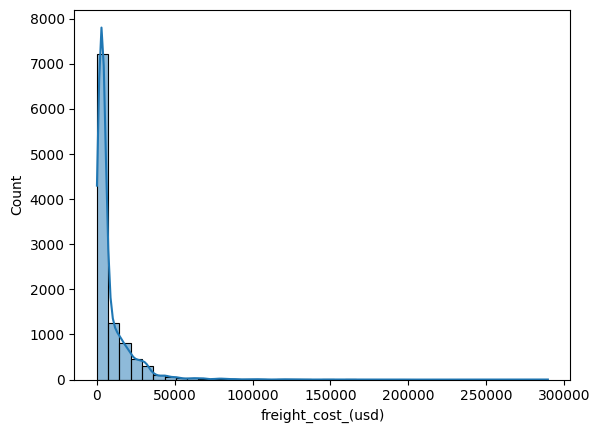

In [30]:
sns.histplot(fedex_df["freight_cost_(usd)"].dropna(), bins=40, kde=True)


#### Chart - 3 Freight Cost by Country (Top 5)

---



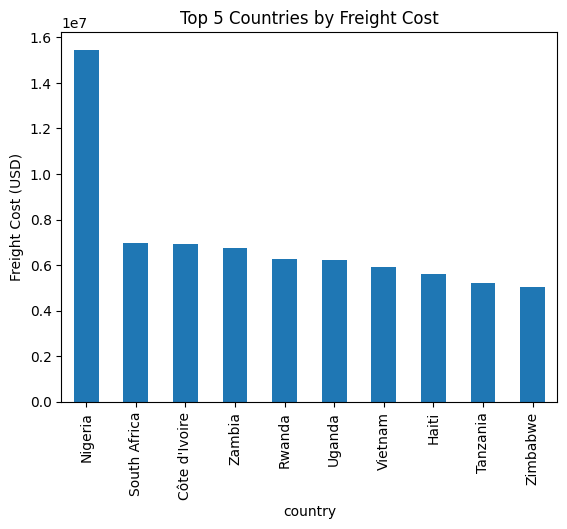

In [31]:
if "country" in fedex_df.columns:
    top5 = fedex_df.groupby("country")["freight_cost_(usd)"].sum().sort_values(ascending=False).head(10)

    top5.plot(kind="bar")
    plt.title("Top 5 Countries by Freight Cost")
    plt.ylabel("Freight Cost (USD)")
    plt.show()

#### Chart - 4 Lead Time By Shippment Mode





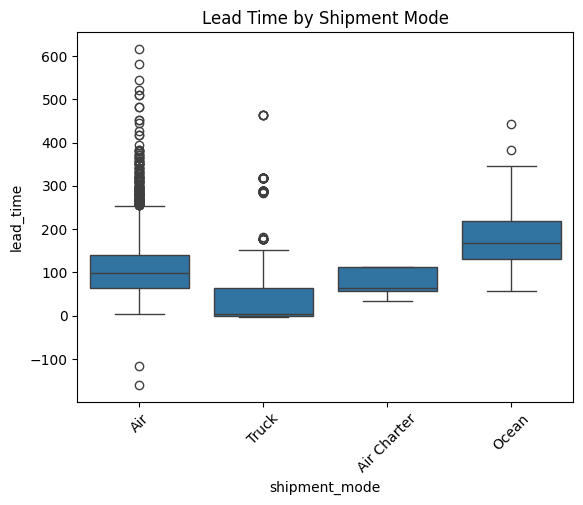

In [32]:
if "shipment_mode" in fedex_df.columns:
    sns.boxplot(x="shipment_mode", y="lead_time", data=fedex_df)
    plt.title("Lead Time by Shipment Mode")
    plt.xticks(rotation=45)
    plt.show()

#### Chart - 5 Monthly On-Time Delivery Trend

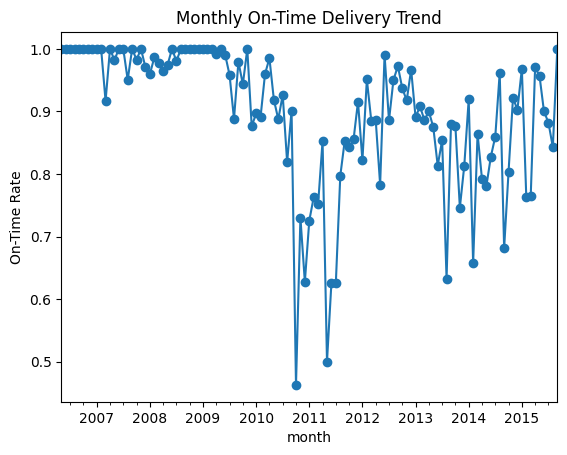

In [33]:
fedex_df["month"] = fedex_df["delivered_to_client_date"].dt.to_period("M")

monthly_ontime = fedex_df.groupby("month")["on_time"].mean()

monthly_ontime.plot(kind="line", marker="o")
plt.title("Monthly On-Time Delivery Trend")
plt.ylabel("On-Time Rate")
plt.show()

#### Chart - 6 Correlation Heatmap

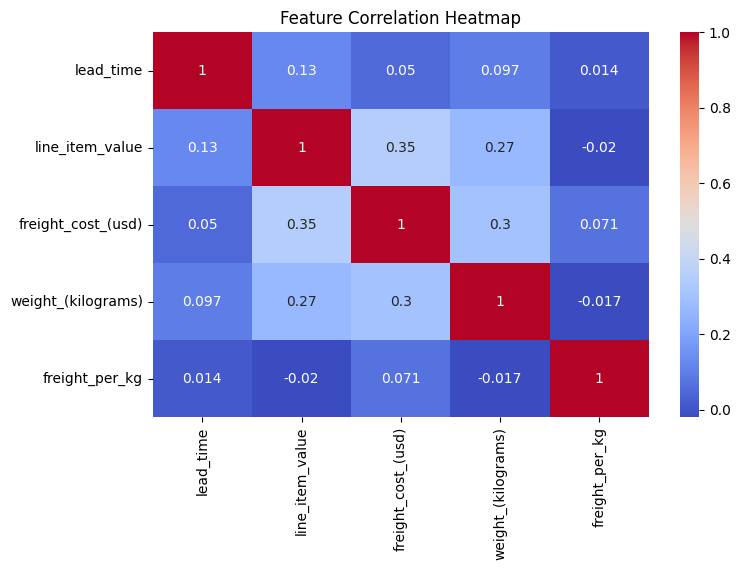

In [34]:
num_df = fedex_df[["lead_time","line_item_value","freight_cost_(usd)","weight_(kilograms)","freight_per_kg"]]

plt.figure(figsize=(8,5))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()